<a href="https://colab.research.google.com/github/ChristineHarvey/InformationLossScore/blob/main/12multiclinsum_pipeline_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MULTICLINSUM INFORMATION LOSS  SCORE


End-to-end NLP pipeline for measuring information loss between Full Clinical Reports and their associated Clinical Summaries, using the MultiClinSum v8 dataset.


PIPELINE


0. Installation and imports
1. Data ingestion
2. preprocessing
5. Embedding generation (and testing)
4. Clinical NER extraction (and testing)
5. Metric computation and Final Information Loss Score
6. Analysis of results
7. Visualisation
8. Export results


EXPECTED DATASET STRUCTURE


project_folder/

    multiclinsum_large-scale_train_en/
        fulltext/
            multiclinsum_ls_en_1.txt
            ...
        summaries/
            multiclinsum_ls_en_1_sum.txt
            ...

    multiclinsum_gs_train_en/
        fulltext/
        summaries/

    multiclinsum_test_en/
        fulltext/
        summaries/

In [1]:
#====================================================================
# 0 - INSTALLATION
#====================================================================
!pip install transformers==4.30.0

!pip install pandas numpy matplotlib scikit-learn scipy
!pip install transformers sentence-transformers
!pip install rouge-score bert-score
#!pip install stanza

# ==================================================================
# 0 - IMPORTS
# ==================================================================

import os
import glob
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### models ####
from transformers import pipeline  #for NER
from sentence_transformers import SentenceTransformer  #for embedding generation

#### metrics ####
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer
from bert_score import score as bertscore


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 10.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 29.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 120.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.0 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.8 MB/s eta 0:00:0

In [2]:
# #mount folder
# from google.colab import drive
# drive.mount('/content/drive/', force_remount=True)

# import os
# import random
# import shutil
# import pandas as pd

# # -----------------------------
# # Folder paths in Google Drive
# # -----------------------------

# source_folder = "/content/drive/MyDrive/MultiClinSum/multiclinsum_large-scale_train_en"

# source_fulltexts = os.path.join(source_folder, "fulltext")
# source_summaries = os.path.join(source_folder, "summaries")

# sample_folder = "/content/drive/MyDrive/MultiClinSum/large-scale_train_sample"

# sample_fulltexts = os.path.join(sample_folder, "fulltext")
# sample_summaries = os.path.join(sample_folder, "summaries")

# # Create destination folders
# os.makedirs(sample_fulltexts, exist_ok=True)
# os.makedirs(sample_summaries, exist_ok=True)


# # -----------------------------
# # Get filenames
# # -----------------------------

# print("Reading filenames...")

# fulltext_files = set(os.listdir(source_fulltexts))
# summary_files = set(os.listdir(source_summaries))

# print("Fulltexts:", len(fulltext_files))
# print("Summaries:", len(summary_files))


# # -----------------------------
# # Find matching pairs
# # -----------------------------

# valid_fulltexts = [
#     filename
#     for filename in fulltext_files
#     if filename.endswith(".txt")
#     and filename.replace(".txt", "_sum.txt") in summary_files
# ]

# print("Valid matched pairs:", len(valid_fulltexts))


# # -----------------------------
# # Randomly sample 3000
# # -----------------------------

# random.seed(42)

# sample_fulltext_files = random.sample(valid_fulltexts, 3000)

# print("Selected:", len(sample_fulltext_files))


# # -----------------------------
# # Copy ONLY the selected files
# # -----------------------------

# print("Copying selected pairs...")

# for i, fulltext_filename in enumerate(sample_fulltext_files):

#     summary_filename = fulltext_filename.replace(
#         ".txt",
#         "_sum.txt"
#     )

#     shutil.copy2(
#         os.path.join(source_fulltexts, fulltext_filename),
#         os.path.join(sample_fulltexts, fulltext_filename)
#     )

#     shutil.copy2(
#         os.path.join(source_summaries, summary_filename),
#         os.path.join(sample_summaries, summary_filename)
#     )

#     # progress indicator
#     if (i + 1) % 100 == 0:
#         print(f"Copied {i + 1}/3000 pairs")


# print("Finished!")

# sample_ids = [
#     filename.replace(".txt", "")
#     for filename in sample_fulltext_files
# ]

# pd.DataFrame({
#     "report_id": sample_ids
# }).to_csv(
#     os.path.join(sample_folder, "sample_ids.csv"),
#     index=False
# )

# print("Sample IDs saved.")

In [4]:
#mount folder
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

#start with MultiClinSum/multiclinsum_gs_train_en/ as prototype then large-scale_train_sample
!cp -r "/content/drive/MyDrive/MultiClinSum/multiclinsum_gs_train_en/" /content/
#print("drive connected to colab")

# ==================================================================
# 1 - DATA INGESTION
# ==================================================================

def load_multiclinsum_dataset(base_folder, dataset_name):
  """
  Loads report-summary pairs from MultiClinSum
  """
  fulltext_folder = os.path.join(base_folder, "fulltext")
  summary_folder = os.path.join(base_folder, "summaries")

  data = []

  report_files = glob.glob(os.path.join(fulltext_folder, "*.txt"))

  print(f"Loading dataset: {dataset_name}")
  print(f"Found {len(report_files)} reports")

  for report_path in report_files:
    report_filename = os.path.basename(report_path)
    # remove .txt
    report_id = report_filename.replace(".txt", "")
    # create matching summary filename
    summary_filename = f"{report_id}_sum.txt"
    summary_path = os.path.join(summary_folder, summary_filename)

    # skip if missing summary
    if not os.path.exists(summary_path):
      print(f"WARNING: Missing summary -> {report_id}")
      continue

    # read report
    with open(report_path, "r", encoding="utf-8") as f:
      report_text = f.read()

    # read summary
    with open(summary_path, "r", encoding="utf-8") as f:
      summary_text = f.read()

    data.append({
      "dataset": dataset_name,
      "report_id": report_id,
      "report_text": report_text,
      "summary_text": summary_text
    })
  return pd.DataFrame(data)

DATASET_FOLDERS = {
  "gold_standard": "/content/multiclinsum_gs_train_en" #,
  #"ls_sample": "/content/large-scale_train_sample"
  #"test": "/content/MultiClinSum/multiclinsum_test_en"
}
all_dfs = []

for dataset_name, folder_path in DATASET_FOLDERS.items():
  if os.path.exists(folder_path):
    dataset_df = load_multiclinsum_dataset(folder_path, dataset_name)
    all_dfs.append(dataset_df)
  else:
    print(f"WARNING: Folder not found -> {folder_path}")

# combine
df = pd.concat(all_dfs, ignore_index=True)

print("Total samples:", len(df))
print("Dataset counts:")
print(df["dataset"].value_counts())


# ==================================================================
# 2 - DATA PREPROCESSING
# ==================================================================

def preprocess_text(text):
  """
  Basic preprocessing
  """
  text = str(text)
  # lowercase
  text = text.lower()
  # remove extra spaces
  text = re.sub(r"\s+", " ", text)
  # replace curly '
  #text = text.replace("’", "'")
  # remove special characters
  #text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
  return text.strip()

print("Preprocessing text")

df["report_clean"] = df["report_text"].apply(preprocess_text)
df["summary_clean"] = df["summary_text"].apply(preprocess_text )

def remove_duplicate_sentences(text):
  sentences = text.strip().split(". ")
  # or sentences = re.split(r'\. ', text.strip())
  return ". ".join(dict.fromkeys(sentences))

df["report_deduplicated"] = df["report_clean"].apply(remove_duplicate_sentences)
df["summary_deduplicated"] = df["summary_clean"].apply(remove_duplicate_sentences)

# Find texts that were changed
changed = df[
  (df["report_clean"] != df["report_deduplicated"]) |
  (df["summary_clean"] != df["summary_deduplicated"])
  ]

print("Preprocessing complete")

# Select columns to export
changed_export = changed[
  [ "report_id",
    "report_clean",
    "report_deduplicated",
    "summary_clean",
    "summary_deduplicated"
  ]
]

# Save to CSV
changed_export.to_csv("changed_reports.csv", index=False)

Mounted at /content/drive/
Loading dataset: gold_standard
Found 592 reports
Total samples: 592
Dataset counts:
dataset
gold_standard    592
Name: count, dtype: int64
Preprocessing text
Preprocessing complete


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.96k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/312 [00:00<?, ?B/s]

Models loaded


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Embeddings generated.
embeddings shape (592, 768)


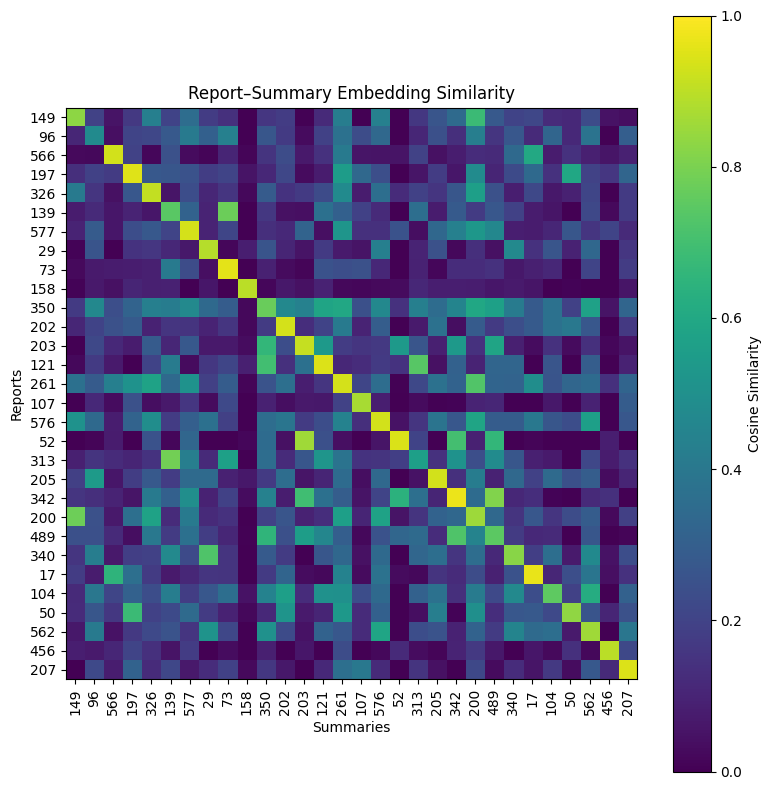

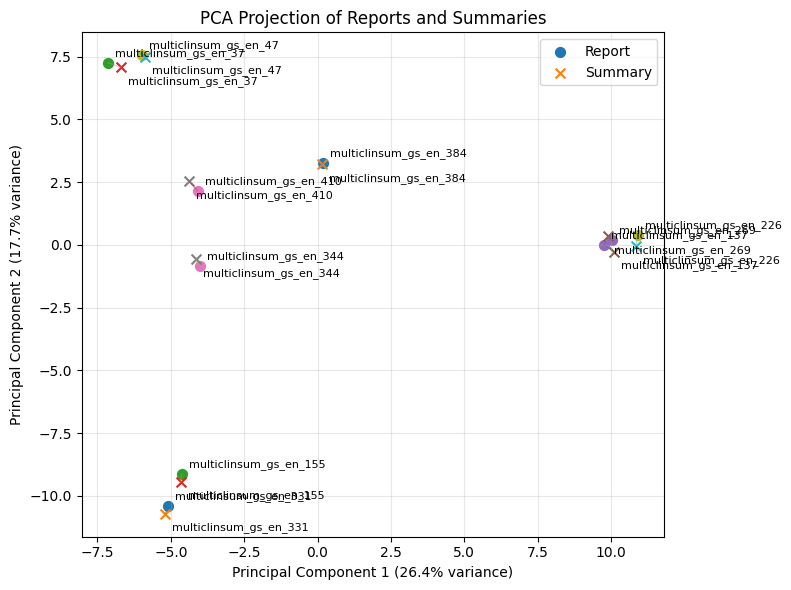

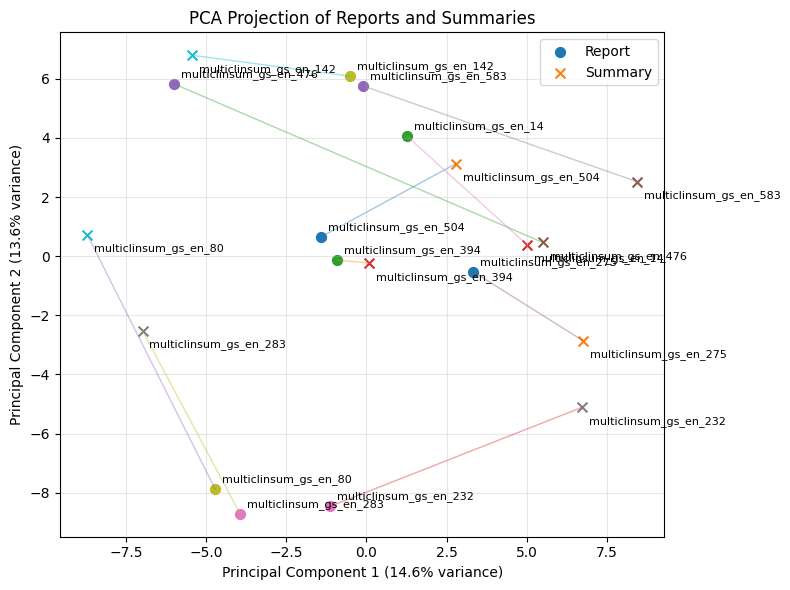

Empty DataFrame
Columns: [report_id, wordcount_diff]
Index: []


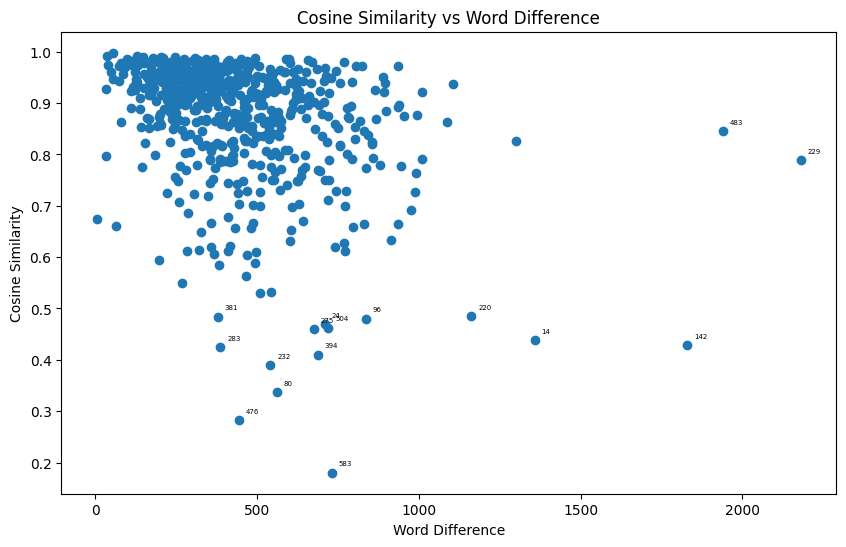

RESULTS SAVED as ls_sample_20.csv


In [5]:
# ==================================================================
# 5 - EMBEDDING GENERATION biomedical
# ==================================================================

#creating Biomedical embeddings from the PubMedBERT-base-embeddings model fined-tuned using sentence-transformers
embedding_biomed = SentenceTransformer("neuml/biomedbert-base-embeddings") #USED FOR ALL SO FAR
##embedding_biomed = SentenceTransformer("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
## was called embedding_biomed = SentenceTransformer("sentence-transformers/BiomedNLP/PubMedBERT-base-uncased-abstract-fulltext")
print("Models loaded")

report_embeddings = embedding_biomed.encode(
    df["report_deduplicated"].tolist(),
    show_progress_bar=True
)

summary_embeddings = embedding_biomed.encode(
    df["summary_deduplicated"].tolist(),
    show_progress_bar=True
)

print("Embeddings generated.")
print("embeddings shape", report_embeddings.shape)  #768-dim vector from biomedbert-base


# ==================================================================
# 6 - CHECKING EMBEDDINGS (using similarity matrix of random 30 reports)
# ==================================================================

#take 30 random embeddings
np.random.seed(222)
random_indices = np.random.choice(len(report_embeddings), size=30, replace=False)
report_emb_30 = report_embeddings[random_indices]
summary_emb_30 = summary_embeddings[random_indices]

#create a similarity matrix
similarity_matrix = cosine_similarity(report_emb_30, summary_emb_30)

#visualise heatmap of similarity matrix
plt.figure(figsize=(8, 8))
plt.imshow(similarity_matrix, cmap="viridis", vmin=0, vmax=1)
plt.xlabel("Summaries")
plt.ylabel("Reports")
#strip prefix from data labels
labels = (df["report_id"].iloc[random_indices].str.replace("multiclinsum_gs_en_", "", regex=False))
plt.xticks(range(30), labels, rotation=90)
plt.yticks(range(30), labels)
plt.title("Report–Summary Embedding Similarity")
plt.colorbar(label="Cosine Similarity")
plt.tight_layout()
plt.show()

# ==================================================================
# CHECKING EMBEDDINGS (using PCA and visualisation)
# ==================================================================

def plotPCA(report_embeddings, summary_embeddings, report_ids):
  from sklearn.decomposition import PCA

  # Combine report and summary embeddings
  combined_embeddings = np.vstack([report_embeddings, summary_embeddings])

  # Fit PCA jointly
  pca = PCA(n_components=2)
  combined_2d = pca.fit_transform(combined_embeddings)

  # Split the PCA results back into reports and summaries
  len_reports = len(report_embeddings)
  report_2d = combined_2d[:len_reports]
  summary_2d = combined_2d[len_reports:]

  # Create paired plot
  plt.figure(figsize=(8, 6))
  for i in range(len_reports):
    # Coordinates
    report_x, report_y = report_2d[i]
    summary_x, summary_y = summary_2d[i]

    # original report_id
    report_id = report_ids[i]

    # Plot report and summary points
    plt.scatter(report_x, report_y, marker="o", s=50)
    plt.scatter(summary_x, summary_y, marker="x", s=50 )

    # Draw line connecting report and summary
    plt.plot( [report_x, summary_x], [report_y, summary_y], alpha=0.4, linewidth=1 )

    # Label with prefix R for report and S for summary
    plt.annotate( report_id, (report_x, report_y), xytext=(5, 5), textcoords="offset points", fontsize=8  )
    plt.annotate( report_id, (summary_x, summary_y), xytext=(5, -12), textcoords="offset points", fontsize=8  )

  # Labels and formatting
  plt.xlabel(f"Principal Component 1 "
    f"({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")

  plt.ylabel(f"Principal Component 2 "
    f"({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")

  plt.title("PCA Projection of Reports and Summaries")
  plt.grid(True, alpha=0.3)
  plt.scatter([], [], marker="o", s=50, label="Report")
  plt.scatter([], [], marker="x", s=50, label="Summary")
  plt.legend()
  plt.tight_layout()
  plt.show()

# ==================================================================
# CHECKING ALL EMBEDDINGS (find top-10 and bottom-10 cosine similarity)
# ==================================================================

#create a similarity matrix overall all the data
similarity_all = cosine_similarity(report_embeddings, summary_embeddings)
paired_similarity = np.diag(similarity_all)   #1D array of cosine similarity between pairs

report_ids = df["report_id"].values
results = pd.DataFrame({
  "report_id": report_ids,
  "cosine_similarity": paired_similarity
})

top_10 = results.nlargest(10, "cosine_similarity")
bottom_10 = results.nsmallest(10, "cosine_similarity")

#inspect top and bottom content/text
def print_pair(res):
  for _, row in res.iterrows():
    report_id = row["report_id"]
    case = df[df["report_id"] == report_id].iloc[0]

    print("=" * 80)
    print(f"Report ID: {report_id}")
    print(f"Cosine similarity: {row['cosine_similarity']:.4f}")

    print("\nREPORT:")
    print(case["report_deduplicated"])

    print("\nSUMMARY:")
    print(case["summary_deduplicated"])


#### Plot PCA for top_10 cosine similarities ####

#get report IDs from top_10
top_ids = top_10["report_id"].values

#find POSITION of each report in the DataFrame
top_indices = np.where(df["report_id"].isin(top_ids))[0]

#get the corresponding embeddings
top_report_embeddings = report_embeddings[top_indices]
top_summary_embeddings = summary_embeddings[top_indices]

#make sure IDs are in the same order as the embeddings
top_ids = df["report_id"].iloc[top_indices].values

#plot PCA for top_10 cosine similarities
plotPCA(
  top_report_embeddings,
  top_summary_embeddings,
  top_ids
)

#### Plot PCA for bottom_10 cosine similarities ####

#get report IDs from bottom_10
bot_ids = bottom_10["report_id"].values

#find POSITION of each report in the DataFrame
bot_indices = np.where(df["report_id"].isin(bot_ids))[0]

#get the corresponding embeddings
bottom_report_embeddings = report_embeddings[bot_indices]
bottom_summary_embeddings = summary_embeddings[bot_indices]

#make sure IDs are in the same order as the embeddings
bot_ids = df["report_id"].iloc[bot_indices].values
#plot PCA for bottom_10 cosine similarities
plotPCA(
  bottom_report_embeddings,
  bottom_summary_embeddings,
  bot_ids
)

# ==================================================================
# CHECKING ALL EMBEDDINGS (word counts vs cosine similarity)
# ==================================================================

#### explore if cosine similarity is proportional to word count similarity ####
#### does higher cosine similarity exist between documents of a similar size? ####

#make a dataframe that has the report_ids and word counts of report_deduplicated and summary_deduplicated
df_wordcounts = df[["report_id", "report_deduplicated", "summary_deduplicated"]].copy()
df_wordcounts["report_word_count"] = df_wordcounts["report_deduplicated"].apply(lambda x: len(x.split()))
df_wordcounts["summary_word_count"] = df_wordcounts["summary_deduplicated"].apply(lambda x: len(x.split()))
df_wordcounts = df_wordcounts.drop(columns=["report_deduplicated", "summary_deduplicated"])
df_wordcounts["wordcount_diff"] = df_wordcounts["report_word_count"] - df_wordcounts["summary_word_count"]
df_wordcounts = df_wordcounts.drop(columns=["report_word_count", "summary_word_count"])
df_wordmerge = pd.merge(results, df_wordcounts, on="report_id")
df_wordmerge = df_wordmerge.sort_values(by="cosine_similarity", ascending=False)

#find any negative word count differences, in case summary not shorter
print(df_wordmerge.loc[df_wordmerge["wordcount_diff"] <= 0, ["report_id", "wordcount_diff"]])

#to simplify labels and select only a few datapoints to label
df_wordmerge["plot_report_id"] = (df_wordmerge["report_id"].str.replace("multiclinsum_gs_en_", "", regex=False))
df_label_rows = df_wordmerge[(df_wordmerge["cosine_similarity"] < 0.5) | (df_wordmerge["wordcount_diff"] > 1500)]

#plot a graph to visualise relationship
plt.figure(figsize=(10, 6))
plt.scatter(df_wordmerge["wordcount_diff"], df_wordmerge["cosine_similarity"])

#add report_id labels
for _, row in df_label_rows.iterrows():
  plt.annotate(
    row["plot_report_id"],
    (row["wordcount_diff"], row["cosine_similarity"]),
    fontsize=5,
    xytext=(5, 5),
    textcoords="offset points"
  )
plt.xlabel("Word Difference")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity vs Word Difference")
plt.show()


# ==================================================================
# CHECKING ALL EMBEDDINGS (quantile sampling to find 20 evenly distributed samples)
# ==================================================================

#create a similarity matrix overall all the data
similarity_all = cosine_similarity(report_embeddings, summary_embeddings)
paired_similarity = np.diag(similarity_all)

report_ids = df["report_id"].values
results = pd.DataFrame({
  "report_id": report_ids,
  "report_deduplicated": df["report_deduplicated"],
  "summary_deduplicated": df["summary_deduplicated"],
  "cosine_similarity": paired_similarity
})

#sort descending
results_sorted = results.sort_values("cosine_similarity",ascending=False).reset_index(drop=True)

#create 20 equally sized groups based on cosine similarity
results_sorted["bin"] = pd.qcut(
  results_sorted["cosine_similarity"],
  q=20,
  labels=False,
  duplicates="drop"
)

#randomly select one report from each bin
sample_20 = (
  results_sorted
  .groupby("bin", group_keys=False)
  .sample(n=1, random_state=222)
  .sort_values("cosine_similarity", ascending=False)
  .reset_index(drop=True)
)

#print_pair(sample_20)

#output sample_20 for human ranking
OUTPUT_FILE = "ls_sample_20.csv"          #renamed for ls_sample
sample_20.to_csv(OUTPUT_FILE, index=False)
print("RESULTS SAVED as", OUTPUT_FILE)


In [6]:
# ==================================================================
# 3 - CLINICAL NER EXTRACTION with Glasgow-AI4BioMed/bioner_medmentions_st21pv
# ==================================================================

#https://huggingface.co/Glasgow-AI4BioMed/bioner_medmentions_st21pv

#load pretrained BiomedBERT finetuned for NER using MedMentions dataset
MODEL_NAME = "Glasgow-AI4BioMed/bioner_medmentions_st21pv"

ner_pipeline = pipeline(
  "token-classification",
  model=MODEL_NAME,
  aggregation_strategy="simple"
)
print(ner_pipeline.model.config.id2label) # to see lebels

#reuse the tokenizer already in NER pipeline
tokenizer = ner_pipeline.tokenizer

def extract_entities(text):
  """
  Extracts clinical named entities (NERs) using BiomedBERT.
  Uses overlapping chunks as some reports are over 512 tokens (BiomedBERT's max).
  """

  #convert text into tokens to pass to the BioClinicalBERT
  tokens = tokenizer(
    text,
    add_special_tokens=False,  #prevent these during chunking
    truncation=False,  #prevents long reports being truncated
    return_offsets_mapping=True
   )

  input_ids = tokens["input_ids"]  #numerical token IDs created by tokeniser
  offsets = tokens["offset_mapping"] #offset of token in original string

  #set chunk size and overlap
  max_tokens = 500  #to allow for max512-special tokens
  overlap = 50  #to reduce splitting a clinical entitiy across chunks
  entities = []

  #process into chunks and extract entities
  start = 0   #first token
  while start < len(input_ids):
    #work out where the chunk ends
    end = min(start + max_tokens, len(input_ids))

    #extracts character positions of this token in the ORIGINAL text
    chunk_start_char = offsets[start][0]
    chunk_end_char = offsets[end-1][1]

    #extract original text rather than decoding token IDs
    chunk_text = text[chunk_start_char:chunk_end_char]

    results = ner_pipeline(chunk_text)

    for entity in results:
      ent_start = entity["start"]
      ent_end = entity["end"]

      #start with the model's predicted boundaries
      word_start = ent_start
      word_end = ent_end

      #expand backwards if prediction starts part-way through a word
      while (word_start > 0 and (chunk_text[word_start - 1].isalnum() or chunk_text[word_start - 1] in "-’'")):
        word_start -= 1

      #expand forwards if prediction ends part-way through a word
      while (word_end < len(chunk_text) and (chunk_text[word_end].isalnum() or chunk_text[word_end] in "-’'")):
        word_end += 1

      #extract exact text from original chunk
      word = chunk_text[word_start:word_end]

      entities.append(word.strip())

    #move forward, keeping overlap
    start += max_tokens - overlap
  return list(dict.fromkeys(entities))  #removes duplicates and preserved order

print("Extracting entities")

df_BioNER = df[["report_id", "report_deduplicated", "summary_deduplicated"]].copy()
df_BioNER["report_entities"] = (df_BioNER["report_deduplicated"].apply(extract_entities))
df_BioNER["summary_entities"] = (df_BioNER["summary_deduplicated"].apply(extract_entities))

print("NER extraction complete")

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (569 > 512). Running this sequence through the model will result in indexing errors


{0: 'O', 1: 'B-Anatomy', 2: 'I-Anatomy', 3: 'B-Chemicals & Drugs', 4: 'I-Chemicals & Drugs', 5: 'B-Concepts & Ideas', 6: 'I-Concepts & Ideas', 7: 'B-Devices', 8: 'I-Devices', 9: 'B-Disorders', 10: 'I-Disorders', 11: 'B-Genes & Molecular Sequences', 12: 'I-Genes & Molecular Sequences', 13: 'B-Geographic Areas', 14: 'I-Geographic Areas', 15: 'B-Living Beings', 16: 'I-Living Beings', 17: 'B-Objects', 18: 'I-Objects', 19: 'B-Occupations', 20: 'I-Occupations', 21: 'B-Organizations', 22: 'I-Organizations', 23: 'B-Phenomena', 24: 'I-Phenomena', 25: 'B-Physiology', 26: 'I-Physiology', 27: 'B-Procedures', 28: 'I-Procedures'}
Extracting entities


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


NER extraction complete


In [7]:
# ==================================================================
# 4 - CHECKING NER EXTRACTION with Glasgow-AI4BioMed/bioner_medmentions_st21pv
# ==================================================================

#df_BioNER_analysis = (df_BioNER.set_index("report_id").loc[sample_20["report_id"]].reset_index())

# #output entities to compare
# OUTPUT_FILE = "BioNER_analysis.csv"
# df_BioNER_analysis.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")
# print("RESULTS SAVED as", OUTPUT_FILE)

#read in the human entities
import ast

df_BioNER_valid = pd.read_csv("/content/drive/MyDrive/MultiClinSum/BioNER_CompVsHumanEDIT.csv")

#convert entity columns from strings back into lists
df_BioNER_valid["report_entities"] = (df_BioNER_valid["report_entities"].apply(ast.literal_eval))
df_BioNER_valid["human_entities"] = (df_BioNER_valid["human_entities"].apply(ast.literal_eval))

def evaluate_ner(human_entities, computer_entities):
  #remove duplicates while preserving order
  human = list(dict.fromkeys(human_entities))
  computer = list(dict.fromkeys(computer_entities))

  ### STRICT MATCHING ###
  strict_matches = []
  strict_false_positives = []
  strict_false_negatives = []

  #true and false positives
  for entity in computer:
    if entity in human:
      strict_matches.append(entity)
    else:
      strict_false_positives.append(entity)

  #false negatives
  for entity in human:
    if entity not in computer:
      strict_false_negatives.append(entity)

  strict_tp = len(strict_matches)
  strict_fp = len(strict_false_positives)
  strict_fn = len(strict_false_negatives)

  #calculate strict p, r and f1
  strict_precision = strict_tp / (strict_tp + strict_fp)
  strict_recall = strict_tp / (strict_tp + strict_fn)
  strict_f1 = (2*strict_precision*strict_recall / (strict_precision + strict_recall))

  ### RELAXED MATCHING ###
  relaxed_matches = []
  matched_human = []
  matched_computer = []

  for h_idx, human_entity in enumerate(human):
    exact_match_found = None
    partial_matches = []

    #check adjacent computer entities for inappropriate splits
    for c_idx in range(len(computer)):
      if c_idx not in matched_computer:
        combined_entity = ""
        #combine adjacent computer entities
        for end_idx in range(c_idx, len(computer)):
          #only continue uf computer entity has not already been used
          if end_idx not in matched_computer:
            if combined_entity == "":
              combined_entity = computer[end_idx]
            else:
              combined_entity = (combined_entity + " " + computer[end_idx])

            #number of words in each entity string
            human_words = len(human_entity.split())
            computer_words = len(combined_entity.split())

            exact_match = (combined_entity == human_entity)
            partial_match = (combined_entity in human_entity or human_entity in combined_entity)

            #only allow partial match if shorter phrase contains at least 3 words
            enough_words = (min(human_words, computer_words) >= 7)

            #store exact match if found
            if exact_match:
              exact_match_found = (c_idx, end_idx, combined_entity)

            #otherwise store possible partial matches
            elif partial_match and enough_words:
              partial_matches.append((c_idx, end_idx, combined_entity))

    #use exact match if one was found
    if exact_match_found is not None:
      c_idx, end_idx, combined_entity = exact_match_found

      relaxed_matches.append((human_entity, combined_entity))
      matched_human.append(h_idx)

      #store all computer entities used
      for i in range(c_idx, end_idx + 1):
        if i not in matched_computer:
          matched_computer.append(i)

    #if no exact match, use the longest partial match
    elif len(partial_matches) > 0:
      longest_match = max(
          partial_matches,
          key=lambda match: len(match[2].split())
      )

      c_idx, end_idx, combined_entity = longest_match

      relaxed_matches.append((human_entity, combined_entity))
      matched_human.append(h_idx)

      #store all computer entities used
      for i in range(c_idx, end_idx + 1):
        if i not in matched_computer:
          matched_computer.append(i)

  relaxed_tp = len(relaxed_matches)
  relaxed_fp = len(computer) - len(matched_computer)
  relaxed_fn = len(human) - len(matched_human)

  #calculate relaxed p, r and f1
  relaxed_precision = relaxed_tp / (relaxed_tp + relaxed_fp)
  relaxed_recall = relaxed_tp / (relaxed_tp + relaxed_fn)
  relaxed_f1 = 2 * relaxed_precision * relaxed_recall / (relaxed_precision + relaxed_recall)

  return pd.Series({
    "strict_TP": strict_tp,
    "strict_FP": strict_fp,
    "strict_FN": strict_fn,
    "strict_precision": strict_precision,
    "strict_recall": strict_recall,
    "strict_F1": strict_f1,

    "relaxed_TP": relaxed_tp,
    "relaxed_FP": relaxed_fp,
    "relaxed_FN": relaxed_fn,
    "relaxed_precision": relaxed_precision,
    "relaxed_recall": relaxed_recall,
    "relaxed_F1": relaxed_f1,

    "strict_matches": strict_matches,
    "strict_false_positives": strict_false_positives,
    "strict_false_negatives": strict_false_negatives,
    "relaxed_matches": relaxed_matches
  })

results = df_BioNER_valid.apply(
  lambda row: evaluate_ner(
    row["human_entities"],
    row["report_entities"]
  ),
  axis=1
)
print(results)

df_BioNER_valid = pd.concat([df_BioNER_valid, results],axis=1)
df_BioNER_valid[
  [
    "report_id",
    "strict_precision",
    "strict_recall",
    "strict_F1",
    "relaxed_precision",
    "relaxed_recall",
    "relaxed_F1"
  ]
]

df_BioNER_valid.to_csv(
  "BioNER_validation_results.csv",
  index=False,
  encoding="utf-8-sig"
)

def micro_avg_results(tp_col, fp_col, fn_col):
  """
  micro-averages scores across all 20 reports
  """
  tp = df_BioNER_valid[tp_col].sum()
  fp = df_BioNER_valid[fp_col].sum()
  fn = df_BioNER_valid[fn_col].sum()

  precision = tp / (tp + fp)
  recall = tp / (tp + fn)
  f1 = 2 * precision * recall / (precision + recall)

  return precision, recall, f1

strict_P, strict_R, strict_F1 = micro_avg_results("strict_TP", "strict_FP", "strict_FN")
relaxed_P, relaxed_R, relaxed_F1 = micro_avg_results("relaxed_TP", "relaxed_FP", "relaxed_FN")

print("STRICT")
print("Precision:", round(strict_P, 3))
print("Recall:   ", round(strict_R, 3))
print("F1:       ", round(strict_F1, 3))

print("\nRELAXED")
print("Precision:", round(relaxed_P, 3))
print("Recall:   ", round(relaxed_R, 3))
print("F1:       ", round(relaxed_F1, 3))



    strict_TP  strict_FP  strict_FN  strict_precision  strict_recall  \
0          47         27         18          0.635135       0.723077   
1          60         19         22          0.759494       0.731707   
2          35         17         11          0.673077       0.760870   
3          55         23         23          0.705128       0.705128   
4          42         19         11          0.688525       0.792453   
5          46         22         14          0.676471       0.766667   
6          61         30         17          0.670330       0.782051   
7          54         38         25          0.586957       0.683544   
8          81         10         15          0.890110       0.843750   
9          57         18         12          0.760000       0.826087   
10         53         38         24          0.582418       0.688312   
11         39          8         12          0.829787       0.764706   
12         54         13         14          0.805970       0.79

In [8]:
# ==================================================================
# 5 - METRIC COMPUTATION
# ==================================================================

# ------------------------------------------------------------------
# ROUGE-L
# ------------------------------------------------------------------

rouge_precision = []
rouge_recall = []
rouge_f1 = []

#creates rouge baseline score using roberta-large default
rouge_scorer_model = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

for report, summary in zip(df["report_deduplicated"], df["summary_deduplicated"]):
  score = rouge_scorer_model.score(report, summary)["rougeL"]
  rouge_precision.append(score.precision)
  rouge_recall.append(score.recall)
  rouge_f1.append(score.fmeasure)

df["ROUGE_L_P"] = rouge_precision
df["ROUGE_L_R"] = rouge_recall
df["ROUGE_L_F1"] = rouge_f1

print("ROUGE-L completed")

# ------------------------------------------------------------------
# BERTScore
# ------------------------------------------------------------------

# #calculate biomedical BERTscore using NeuML model based on PubMedBERT
# #replace neuml/biomedbert-base-embeddings
# bioP, bioR, bioF1 = bertscore(
#   df["summary_deduplicated"].tolist(),
#   df["report_deduplicated"].tolist(),
#   model_type="microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext",
#   num_layers=12,
#   verbose=True
# )
# df["BiomedBERTScore_P"] = bioP.numpy()
# df["BiomedBERTScore_R"] = bioR.numpy()
# df["BiomedBERTScore_F1"] = bioF1.numpy()
# print("BiomedBERTScore completed")

# -------------------------------------------------
# Function for chunk-aggregated BERTScore
# -------------------------------------------------
from transformers import AutoTokenizer
from bert_score import BERTScorer

def calculate_chunked_bertscore(
  df,
  model_name,
  prefix,
  num_layers=None,
  max_tokens=500
):

  #load tokenizer
  tokenizer = AutoTokenizer.from_pretrained(model_name  )
  tokenizer.model_max_length = 512

  #load BERTScore model once
  scorer = BERTScorer(model_type=model_name, num_layers=num_layers,lang="en")
  scorer._tokenizer.model_max_length = 512

  results = []

  for count, row in df.iterrows():
    report = row["report_deduplicated"]
    summary = row["summary_deduplicated"]

    #tokenise complete report
    report_tokens = tokenizer.encode(
        report,
        add_special_tokens=False,
        truncation=False
    )

    chunk_scores_P = []
    chunk_scores_R = []
    chunk_scores_F1 = []
    chunk_weights = []

    #split report into 500-token chunks
    for start in range(0, len(report_tokens), max_tokens):
        chunk_tokens = report_tokens[start:start + max_tokens]
        chunk_text = tokenizer.decode(chunk_tokens, skip_special_tokens=True)

        #compare report chunk with full summary
        P, R, F1 = scorer.score([summary], [chunk_text])

        chunk_scores_P.append(P.item())
        chunk_scores_R.append(R.item())
        chunk_scores_F1.append(F1.item())

        #weight according to number of tokens
        chunk_weights.append(len(chunk_tokens))

    #weighted mean across report chunks
    P_mean = np.average(chunk_scores_P, weights=chunk_weights)
    R_mean = np.average(chunk_scores_R, weights=chunk_weights)
    F1_mean = np.average(chunk_scores_F1, weights=chunk_weights)

    results.append((P_mean, R_mean, F1_mean))
    print(f"\r{prefix}: {len(results)}/{len(df)} completed", end="", flush=True)

  #add results to dataframe
  df[
    [ f"{prefix}_BERTScore_P",
      f"{prefix}_BERTScore_R",
      f"{prefix}_BERTScore_F1"]
  ] = results

  #calculate semantic loss
  df[f"{prefix}_BERTdiff_R"] = (1 - df[f"{prefix}_BERTScore_R"])


### RoBERTa-large chunk-aggregated BERTScore ###

calculate_chunked_bertscore(
    df=df,
    model_name="roberta-large",
    prefix="RoBERTa",
    num_layers=17,
    max_tokens=500
)
print("RoBERTa-large chunked BERTScore completed")


### BiomedBERT chunk-aggregated BERTScore ###

calculate_chunked_bertscore(
    df=df,
    model_name="microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext",
    prefix="NewBiomed",
    num_layers=12,
    max_tokens=500
)
print("BiomedBERT chunked BERTScore completed")


### Clinical-Longformer BERTScore ###

MODEL_NAME = "yikuan8/Clinical-Longformer"
import torch
torch.cuda.empty_cache()

#load model once
scorer_longformer = BERTScorer(
    model_type=MODEL_NAME,
    num_layers=12,
    lang="en",
    batch_size=1
)
longformer_results = []

for count, row in enumerate(df.itertuples(index=False), start=1):
  #score ONE report-summary pair at a time
  P, R, F1 = scorer_longformer.score(
    [row.summary_deduplicated],
    [row.report_deduplicated],
    batch_size=1
  )
  longformer_results.append( (P.item(), R.item(), F1.item()) )

  #clear unused GPU memory periodically
  torch.cuda.empty_cache()
  print(f"\rClinical-Longformer: {len(results)}/{len(df)} completed", end="", flush=True)

#add scores to dataframe
df[
  [ "ClinicalLongformer_BERTScore_P",
    "ClinicalLongformer_BERTScore_R",
    "ClinicalLongformer_BERTScore_F1"]
] = longformer_results

print("Clinical-Longformer BERTScore completed")
print("All BERTdifferences completed")


# # ------------------------------------------------------------------
# # EMBEDDING COSINE SIMILARITY (EMBEDDINGS GENERATED ABOVE)
# # ------------------------------------------------------------------

# cosine_scores = []
# for report_emb, summary_emb in zip(report_embeddings, summary_embeddings):
#   similarity = cosine_similarity([report_emb], [summary_emb])[0][0]
#   cosine_scores.append(similarity)
# df["Embedding_Cosine"] = cosine_scores
# print("Embedding_Cosine completed")


# ------------------------------------------------------------------
# ENTITY RECALL + ENTITY LOSS (ENTITIES EXTRACTED ABOVE in df_BioNER)
# ------------------------------------------------------------------

def compute_entity_recall(report_entities, summary_entities):
  report_set = set(report_entities)
  summary_set = set(summary_entities)
  if len(report_set) == 0:
      return 0
  overlap = report_set.intersection(summary_set)
  return len(overlap) / len(report_set)

entity_recalls = []
for report_entities, summary_entities in zip(df_BioNER["report_entities"], df_BioNER["summary_entities"]):
  recall = compute_entity_recall(report_entities, summary_entities)
  entity_recalls.append(recall)
df["Entity_Recall"] = entity_recalls

# NB information loss
df["NER_Loss"] = 1 - df["Entity_Recall"]
print("Entity loss completed")


ROUGE-L completed


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

[transformers] LongformerModel LOAD REPORT from: yikuan8/Clinical-Longformer
Key                                | Status     | 
-----------------------------------+------------+-
lm_head.layer_norm.weight          | UNEXPECTED | 
lm_head.dense.weight               | UNEXPECTED | 
lm_head.decoder.bias               | UNEXPECTED | 
lm_head.decoder.weight             | UNEXPECTED | 
longformer.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias                 | UNEXPECTED | 
lm_head.layer_norm.bias            | UNEXPECTED | 
lm_head.bias                       | UNEXPECTED | 
pooler.dense.weight                | MISSING    | 
pooler.dense.bias                  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Input ids are automatically padded to be a multi

Clinical-Longformer: 20/592 completed

model.safetensors: reconstructing file:   0%|          |  0.00B /  595MB            

model.safetensors: downloading bytes:           |  0.00B            

Clinical-Longformer: 20/592 completedClinical-Longformer BERTScore completed
All BERTdifferences completed
Entity loss completed


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] Token indices sequence length is longer than the specified maximum sequence l

(30, 30) done30/30 reports completed
All similarity matrices completed


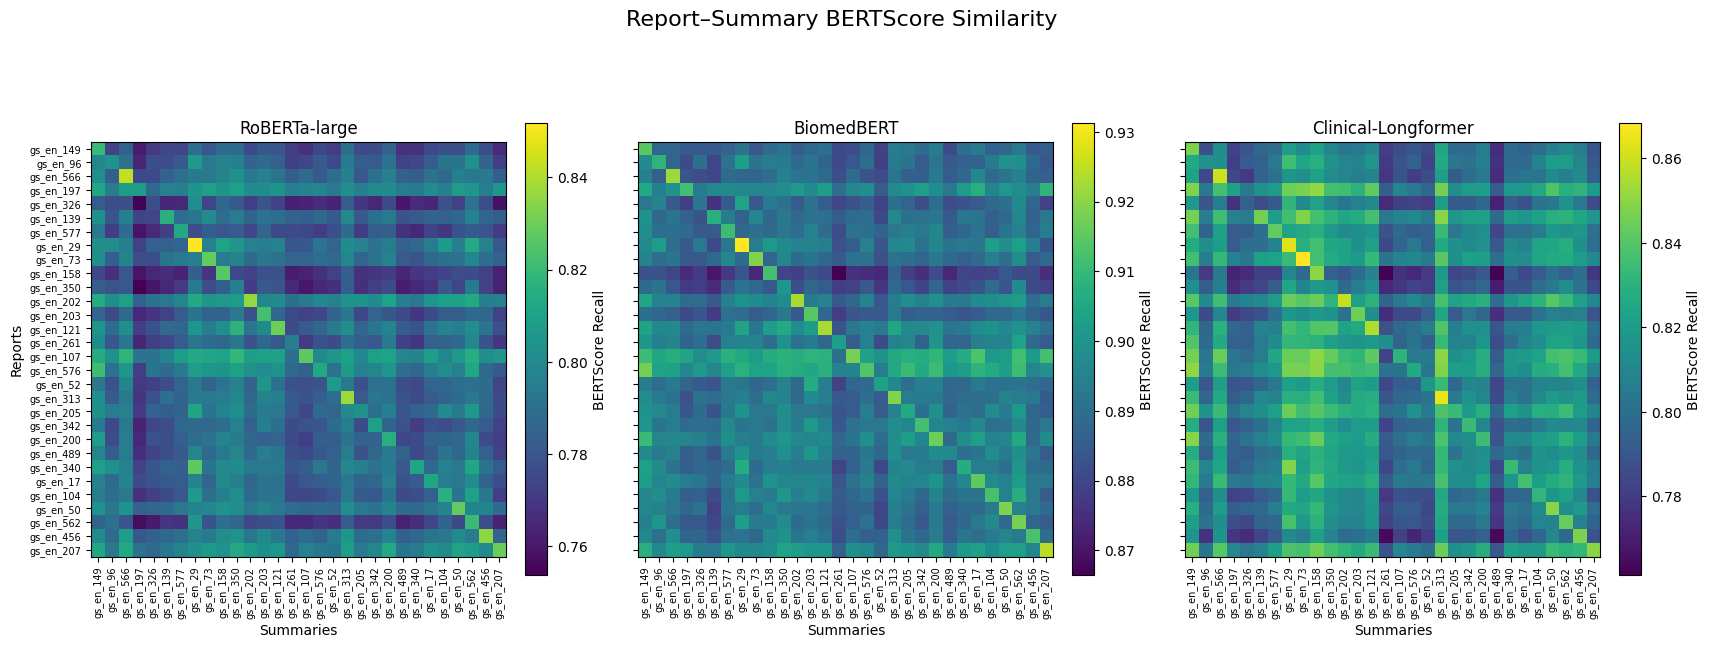

In [9]:
# ==================================================================
# 3 - EXPERIMENTAL
# ==================================================================

#reuse 3 x BERT score and put that in similarity matrix instead of cosine
# replace different models and compare

### companion function ###
def calculate_chunked_bertscore_pair(
  report,
  summary,
  scorer,
  tokenizer,
  max_tokens=500
):
  """
  Calculate chunk-aggregated BERTScore for one report-summary pair.
  The report is split into token-safe chunks.
  The complete summary is compared with each report chunk.
  Chunk scores are weighted by report chunk length.
  """

  # tokenise complete report without truncation
  report_tokens = tokenizer(
      report,
      add_special_tokens=False,
      truncation=False,
      return_attention_mask=False
  )["input_ids"]

  chunk_scores_P = []
  chunk_scores_R = []
  chunk_scores_F1 = []
  chunk_weights = []

  # split report into chunks
  for start in range(0, len(report_tokens), max_tokens):
    chunk_tokens = report_tokens[start:start + max_tokens]
    chunk_text = tokenizer.decode( chunk_tokens, skip_special_tokens=True, clean_up_tokenization_spaces=False )

    # compare full summary with report chunk
    P, R, F1 = scorer.score( [summary], [chunk_text] )

    chunk_scores_P.append(P.item())
    chunk_scores_R.append(R.item())
    chunk_scores_F1.append(F1.item())

    # weight by number of tokens in chunk
    chunk_weights.append(len(chunk_tokens))

  # weighted mean across report chunks
  P_mean = np.average( chunk_scores_P, weights=chunk_weights )
  R_mean = np.average( chunk_scores_R, weights=chunk_weights )
  F1_mean = np.average( chunk_scores_F1, weights=chunk_weights )

  return P_mean, R_mean, F1_mean

# RoBERTa-large
roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-large")
#roberta_tokenizer.model_max_length = 512
scorer_roberta = BERTScorer(model_type="roberta-large", num_layers=17, lang="en")

# BiomedBERT
biomed_tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
#biomed_tokenizer.model_max_length = 512
scorer_biomed = BERTScorer( model_type="microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext", num_layers=12, lang="en")
scorer_biomed._tokenizer.model_max_length = 512


# ==================================================================
# CHECKING BERTScores (using similarity matrix of random 30 reports)
# ==================================================================

# use the same 30 random indices as your cosine similarity heatmap
reports_30 = df["report_deduplicated"].iloc[random_indices].tolist()
summaries_30 = df["summary_deduplicated"].iloc[random_indices].tolist()

n = len(reports_30)

# empty matrices
RoBERTa_matrix = np.zeros((n, n))
Biomed_matrix = np.zeros((n, n))
ClinicalLongformer_matrix = np.zeros((n, n))

# compare every report with every summary
for i, report in enumerate(reports_30):
  for j, summary in enumerate(summaries_30):

    # RoBERTa-large
    P, R, F1 = calculate_chunked_bertscore_pair(
      report=report,
      summary=summary,
      scorer=scorer_roberta,
      tokenizer=roberta_tokenizer,
      max_tokens=500
    )
    RoBERTa_matrix[i, j] = R

    # BiomedBERT
    P, R, F1 = calculate_chunked_bertscore_pair(
      report=report,
      summary=summary,
      scorer=scorer_biomed,
      tokenizer=biomed_tokenizer,
      max_tokens=500
    )
    Biomed_matrix[i, j] = R

    # Clinical-Longformer
    P, R, F1 = scorer_longformer.score(
      [summary],
      [report],
      batch_size=1
    )
    ClinicalLongformer_matrix[i, j] = R.item()
    print(f"\r{i+1,j+1} done", end="", flush=True)
  torch.cuda.empty_cache()

  print(f"{i+1}/{n} reports completed", end="", flush=True)
print("\nAll similarity matrices completed")

# strip prefix from report IDs
labels = (df["report_id"].iloc[random_indices].str.replace("multiclinsum_", "", regex=False))

# shared colour range across all three matrices
vmin = min(RoBERTa_matrix.min(),Biomed_matrix.min(),ClinicalLongformer_matrix.min())
vmax = max(RoBERTa_matrix.max(),Biomed_matrix.max(),ClinicalLongformer_matrix.max())

# create three plots
fig, axes = plt.subplots(1,3, figsize=(20, 7), sharex=True, sharey=True)
matrices = [ RoBERTa_matrix, Biomed_matrix, ClinicalLongformer_matrix ]
titles = [ "RoBERTa-large", "BiomedBERT", "Clinical-Longformer" ]

for ax, matrix, title in zip(axes, matrices, titles):
  vmin = matrix.min()
  vmax = matrix.max()
  im = ax.imshow(
    matrix,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
  )
  ax.set_title(title)
  ax.set_xlabel("Summaries")

  ax.set_xticks(range(n))
  ax.set_xticklabels(labels, rotation=90, fontsize=7)

  ax.set_yticks(range(n))
  ax.set_yticklabels(labels, fontsize=7)

  cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.0496, pad=0.04)
  cbar.set_label("BERTScore Recall")

# y-axis label only needed once
axes[0].set_ylabel("Reports")

fig.suptitle("Report–Summary BERTScore Similarity", fontsize=16)

plt.show()

In [11]:
### looking for mismatched pairs in alternate BERTscores
#quantitaive

# extract matched (diagonal) and mismatched (off-diagonal) scores
def get_diagonal_scores(matrix):
  diagonal = np.diag(matrix)
  off_diag = matrix[~np.eye(matrix.shape[0], dtype=bool)]
  return diagonal, off_diag

Biomed_diagonal, Biomed_off_diag = get_diagonal_scores(Biomed_matrix)
RoBERTa_diagonal, RoBERTa_off_diag = get_diagonal_scores(RoBERTa_matrix)
ClinicalLongformer_diagonal, ClinicalLongformer_off_diag = get_diagonal_scores(ClinicalLongformer_matrix)

results = pd.DataFrame({
  "BiomedBERT": [
    Biomed_diagonal.mean(),
    Biomed_off_diag.mean(),
    Biomed_diagonal.mean() - Biomed_off_diag.mean()
  ],
  "RoBERTa-large": [
    RoBERTa_diagonal.mean(),
    RoBERTa_off_diag.mean(),
    RoBERTa_diagonal.mean() - RoBERTa_off_diag.mean()
  ],
  "Clinical-Longformer": [
    ClinicalLongformer_diagonal.mean(),
    ClinicalLongformer_off_diag.mean(),
    ClinicalLongformer_diagonal.mean() - ClinicalLongformer_off_diag.mean()
  ]
}, index=[
  "Matched mean",
  "Mismatched mean",
  "Difference"
])

display(results.round(4))


def evaluate_matrix(matrix):
  ranks = []
  for i in range(matrix.shape[0]):

    # scores for all summaries for this report
    scores = matrix[i, :]
    # score of the correct summary
    correct_score = matrix[i, i]
    # rank correct summary (1 = highest)
    rank = 1 + np.sum(scores > correct_score)
    ranks.append(rank)
  ranks = np.array(ranks)

  return {
      "Top-1 accuracy": np.mean(ranks == 1),
      "Top-3 accuracy": np.mean(ranks <= 3),
      "Mean rank": np.mean(ranks),
      "Median rank": np.median(ranks),
      "MRR": np.mean(1 / ranks)
  }

ranking_results = pd.DataFrame({
    "BiomedBERT": evaluate_matrix(Biomed_matrix),
    "RoBERTa-large": evaluate_matrix(RoBERTa_matrix),
    "Clinical-Longformer": evaluate_matrix(ClinicalLongformer_matrix)
})

display(ranking_results.round(3))

,BiomedBERT,RoBERTa-large,Clinical-Longformer
Matched mean,0.9129,0.8173,0.8377
Mismatched mean,0.8920,0.7873,0.8105
Difference,0.0209,0.0300,0.0272


,BiomedBERT,RoBERTa-large,Clinical-Longformer
Top-1 accuracy,0.800,0.733,0.500
Top-3 accuracy,0.933,0.900,0.600
Mean rank,1.567,2.300,5.400
Median rank,1.000,1.000,1.500
MRR,0.876,0.810,0.587


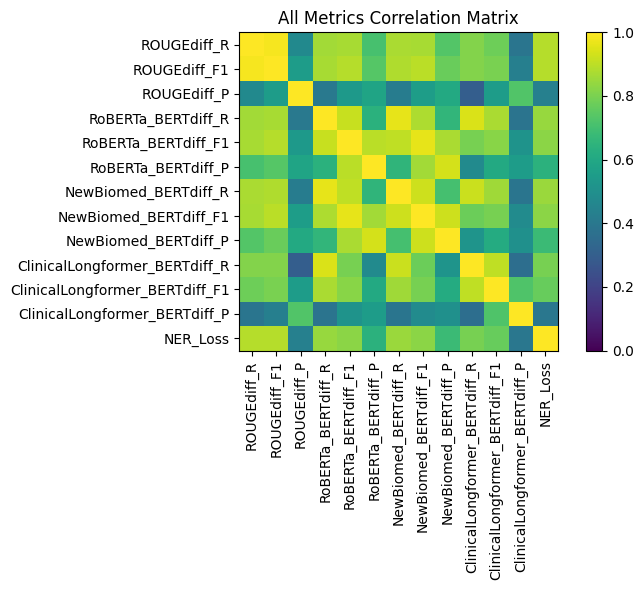

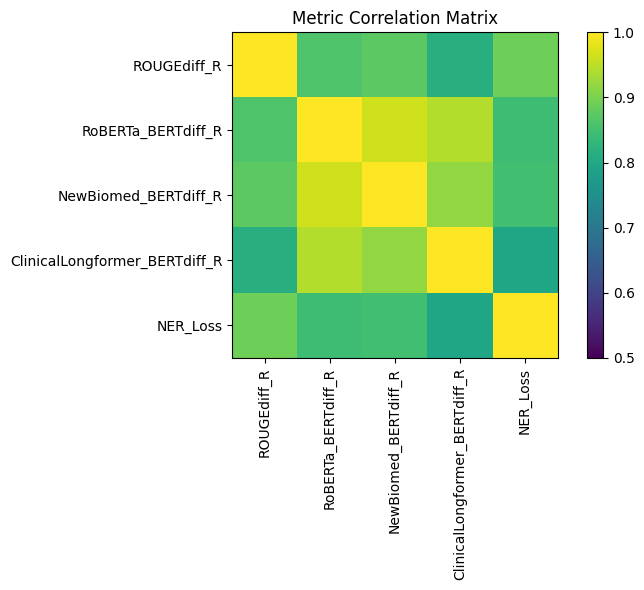

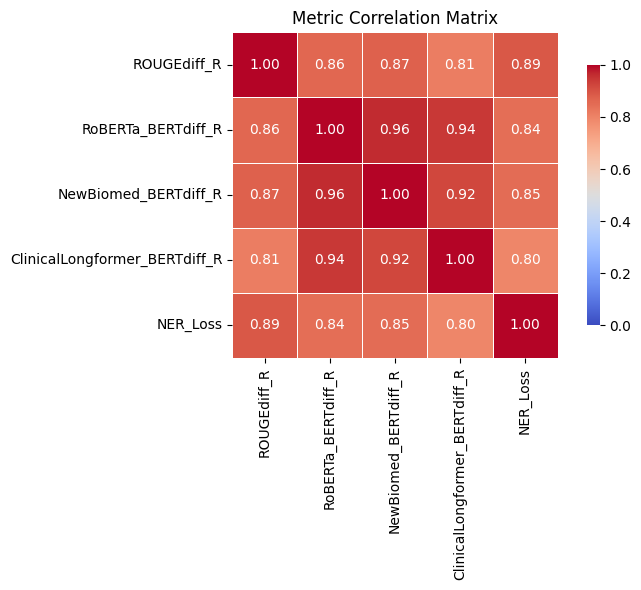

RoBERTa_BERTdiff_R                  rho=0.732, p=0.000
NewBiomed_BERTdiff_R                rho=0.638, p=0.002
ClinicalLongformer_BERTdiff_R       rho=0.605, p=0.005
Human CORRELATION MATRIX


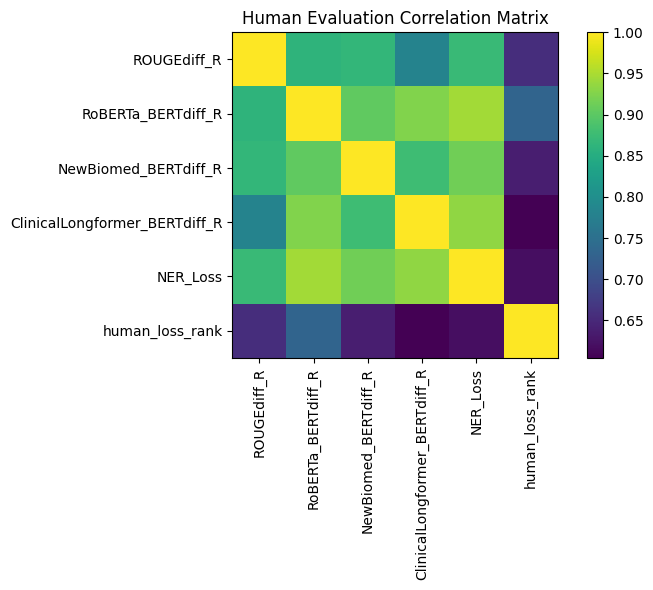

single-column correlation


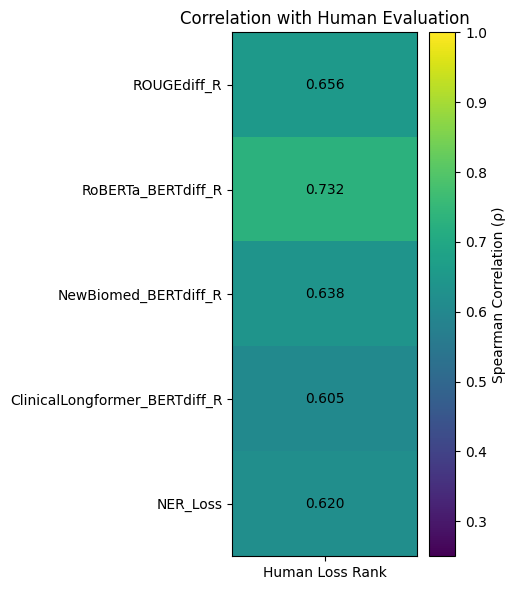

In [12]:
# ==================================================================
# 5 - EDA
# ==================================================================

#convert ROUGE, BiomedBERT and cosine into differences instead of similarities
df['ROUGEdiff_R'] = 1- df['ROUGE_L_R']
df['ROUGEdiff_P'] = 1- df['ROUGE_L_P']
df['ROUGEdiff_F1'] = 1- df['ROUGE_L_F1']

#calculate semantic information loss
#df['Cosinediff_norm'] = 1- ((df['Embedding_Cosine']+1)/2)  # as in range 0-2 not 0-1
df["RoBERTa_BERTdiff_R"] = (1 - df["RoBERTa_BERTScore_R"])
df["RoBERTa_BERTdiff_F1"] = (1 - df["RoBERTa_BERTScore_F1"])
df["RoBERTa_BERTdiff_P"] = (1 - df["RoBERTa_BERTScore_P"])
df["NewBiomed_BERTdiff_R"] = (1 - df["NewBiomed_BERTScore_R"])
df["NewBiomed_BERTdiff_F1"] = (1 - df["NewBiomed_BERTScore_F1"])
df["NewBiomed_BERTdiff_P"] = (1 - df["NewBiomed_BERTScore_P"])
df["ClinicalLongformer_BERTdiff_R"] = (1 - df["ClinicalLongformer_BERTScore_R"])
df["ClinicalLongformer_BERTdiff_F1"] = (1 - df["ClinicalLongformer_BERTScore_F1"])
df["ClinicalLongformer_BERTdiff_P"] = (1 - df["ClinicalLongformer_BERTScore_P"])

all_metrics = [
  "ROUGEdiff_R",
  "ROUGEdiff_F1",
  "ROUGEdiff_P",
  #"Cosinediff_norm",
  "RoBERTa_BERTdiff_R",
  "RoBERTa_BERTdiff_F1",
  "RoBERTa_BERTdiff_P",
  "NewBiomed_BERTdiff_R",
  "NewBiomed_BERTdiff_F1",
  "NewBiomed_BERTdiff_P",
  "ClinicalLongformer_BERTdiff_R",
  "ClinicalLongformer_BERTdiff_F1",
  "ClinicalLongformer_BERTdiff_P",
  "NER_Loss",
]

correlation_metrics = [
    "ROUGEdiff_R",
    "RoBERTa_BERTdiff_R",
    "NewBiomed_BERTdiff_R",
    "ClinicalLongformer_BERTdiff_R",
    "NER_Loss"
]

correlation_all = df[all_metrics].corr(method="pearson")
correlation_matrix = df[correlation_metrics].corr(method="pearson")

### METRIC CORRELATION HEATMAP ###

# PLOT ALL
plt.figure(figsize=(8, 6))
plt.imshow(correlation_all, vmin=0, vmax=1)
plt.xticks(
    range(len(correlation_all.columns)),
    correlation_all.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation_all.columns)),
    correlation_all.columns
)
plt.colorbar()
plt.title("All Metrics Correlation Matrix")
plt.tight_layout()
plt.show()


# PLOT CORR
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, vmin=0.5, vmax=1)
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.colorbar()
plt.title("Metric Correlation Matrix")
plt.tight_layout()
plt.show()

# alternative in seaborn
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,          # show values in cells
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",
    vmin=0,            # lower limit
    vmax=1,            # upper limit
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.xticks(rotation=90, ha="center")
plt.yticks(rotation=0)
plt.title("Metric Correlation Matrix")
plt.tight_layout()
plt.show()



### HUMAN EVALUATION ###

#exporting 20 samples for manual evaluation

# # Sort from lowest apparent loss to highest apparent loss
# df_sorted = df.sort_values("ILS_50_50").reset_index(drop=True)

# # Select 20 evenly spaced cases across the whole range
# indices = np.linspace(0, len(df_sorted)-1, 20, dtype=int)

# sample_ILS_50_50 = df_sorted.iloc[indices].copy()
# sample_ILS_50_50[["report_id", "report_deduplicated","summary_deduplicated"]].to_csv(
#   "human_evaluation_20.csv",
#   index=False,
#   encoding="utf-8-sig"
# )

#importing manual evaluation scores
df_human_eval = pd.read_csv("/content/drive/MyDrive/MultiClinSum/human_eval_rank.csv")
df_merged = df.set_index("report_id").merge(
    df_human_eval.set_index("report_id"),
    left_index=True,
    right_index=True,
    how="inner"
)

## comparing BERTscores with human judgement ###
from scipy.stats import spearmanr

bert_metrics = [
    "RoBERTa_BERTdiff_R",
    "NewBiomed_BERTdiff_R",
    "ClinicalLongformer_BERTdiff_R"
]

for metric in bert_metrics:
    rho, p = spearmanr(
        df_merged["human_loss_rank"],
        df_merged[metric]
    )

    print(f"{metric:35s} rho={rho:.3f}, p={p:.3f}")

### SPEARMAN'S CORRELATION HEATMAP ###

from scipy.stats import spearmanr

human_metrics = [
    "ROUGEdiff_R",
    "RoBERTa_BERTdiff_R",
    "NewBiomed_BERTdiff_R",
    "ClinicalLongformer_BERTdiff_R",
    "NER_Loss",
    "human_loss_rank"
]

print("Human CORRELATION MATRIX")
human_correlation_matrix = df_merged[human_metrics].corr( method="spearman")

# PLOT
plt.figure(figsize=(8, 6))
plt.imshow(human_correlation_matrix)
plt.xticks(
    range(len(human_correlation_matrix.columns)),
    human_correlation_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(human_correlation_matrix.columns)),
    human_correlation_matrix.columns
)
plt.colorbar()
plt.title("Human Evaluation Correlation Matrix")
plt.tight_layout()
plt.show()

print("single-column correlation")

#correlation of each metric with human evaluation
human_correlations = human_correlation_matrix[
    ["human_loss_rank"]
].drop("human_loss_rank")

plt.figure(figsize=(5, 6))

plt.imshow(
    human_correlations,
    cmap="viridis",
    vmin=0.25,
    vmax=1,
    aspect="auto"
)

plt.xticks([0], ["Human Loss Rank"])

plt.yticks(
    range(len(human_correlations)),
    human_correlations.index
)

plt.colorbar(label="Spearman Correlation (ρ)")

#add correlation values
for i, value in enumerate(human_correlations["human_loss_rank"]):
    plt.text(
        0,
        i,
        f"{value:.3f}",
        ha="center",
        va="center"
    )

plt.title("Correlation with Human Evaluation")

plt.tight_layout()
plt.show()

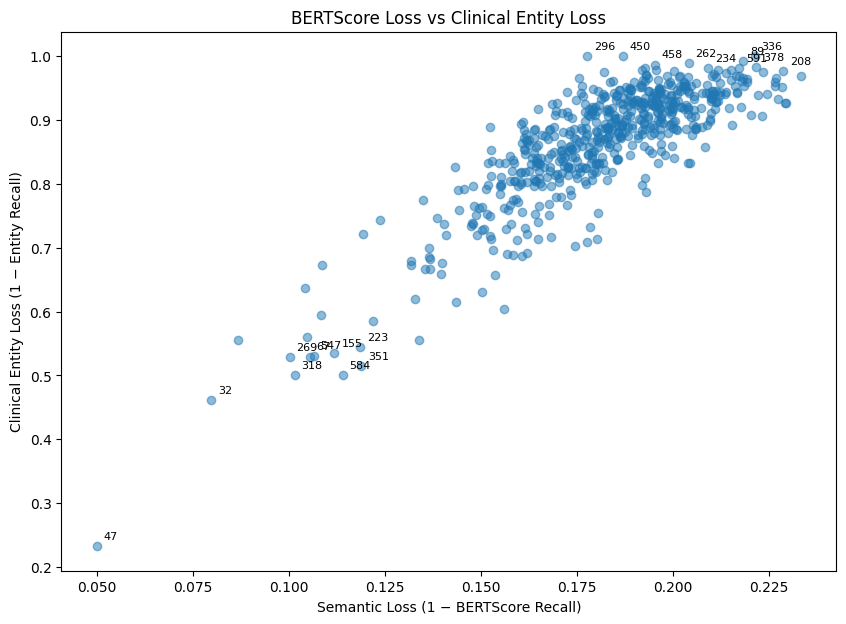

In [13]:

# ==================================================================
# 6 - INFORMATION LOSS SCORE CANDIDATES
# ==================================================================


# Stronger emphasis on semantic retention
df["ILS_30_70"] = (0.30 * df["NER_Loss"] + 0.70 * df["RoBERTa_BERTdiff_R"])

# Slightly more emphasis on semantic retention
df["ILS_40_60"] = (0.40 * df["NER_Loss"] + 0.60 * df["RoBERTa_BERTdiff_R"])

# Equal weighting
df["ILS_50_50"] = (0.50 * df["NER_Loss"] + 0.50 * df["RoBERTa_BERTdiff_R"])

# Slightly more emphasis on clinical entity retention
df["ILS_60_40"] = (0.60 * df["NER_Loss"] + 0.40 * df["RoBERTa_BERTdiff_R"])

# Stronger emphasis on clinical entity retention
df["ILS_70_30"] = (0.70 * df["NER_Loss"] + 0.30 * df["RoBERTa_BERTdiff_R"])

# Normalised distance from the ideal point (0 NER loss, 0 semantic loss)
df["ILS_Distance_norm"] = np.sqrt(df["NER_Loss"]**2 + df["RoBERTa_BERTdiff_R"]**2) / np.sqrt(2)



### scatter plot of entity loss against chosen BERTdiff (1-BERTscore) ###

# Select 10 best and 10 worst
best_10 = df.nsmallest(10, "ILS_Distance_norm")
worst_10 = df.nlargest(10, "ILS_Distance_norm")
outliers = pd.concat([best_10, worst_10])

plt.figure(figsize=(10, 7))
plt.scatter(df["RoBERTa_BERTdiff_R"], df["NER_Loss"], alpha=0.5)
#label the outliers
for _, row in outliers.iterrows():
  label = row["report_id"].replace("multiclinsum_gs_en_", "")
  plt.annotate(
      label,
      (row["RoBERTa_BERTdiff_R"], row["NER_Loss"]),
      xytext=(5, 5),
      textcoords="offset points",
      fontsize=8
  )
plt.xlabel("Semantic Loss (1 − BERTScore Recall)")
plt.ylabel("Clinical Entity Loss (1 − Entity Recall)")
plt.title("BERTScore Loss vs Clinical Entity Loss")
plt.show()

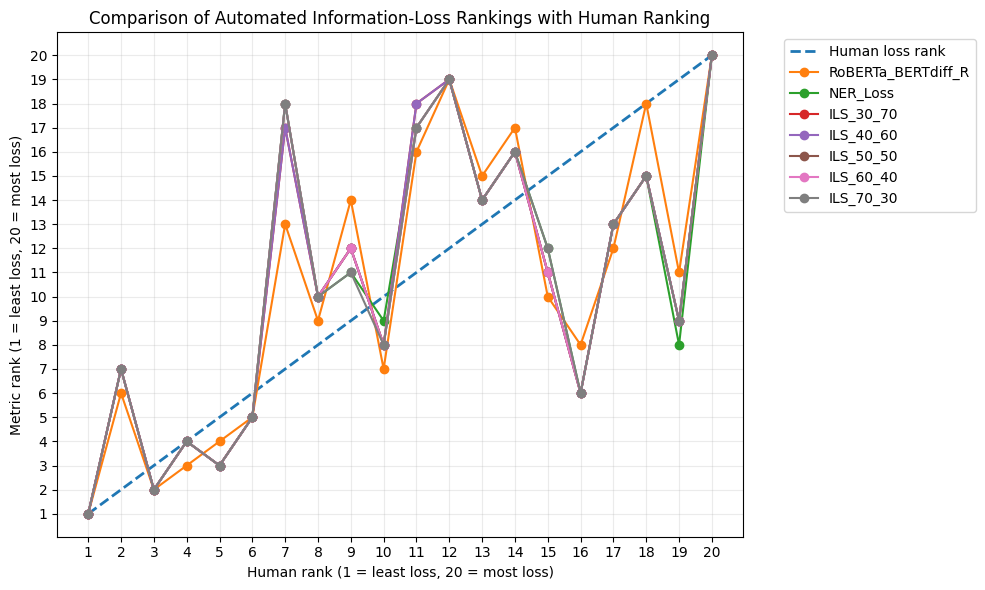

                 report_id  NER_Loss  RoBERTa_BERTdiff_R_rank  ILS_50_50
147  multiclinsum_gs_en_47  0.232558                 0.001689   0.141274
589  multiclinsum_gs_en_32  0.461538                 0.003378   0.270675
                report_id  NER_Loss  RoBERTa_BERTdiff_R  ILS_50_50
6  multiclinsum_gs_en_336       1.0            0.221248   0.610624
                  report_id  NER_Loss  RoBERTa_BERTdiff_R  ILS_50_50
223  multiclinsum_gs_en_296       1.0            0.177579   0.588789
                  report_id  NER_Loss  RoBERTa_BERTdiff_R  ILS_50_50
123  multiclinsum_gs_en_463  0.832335            0.203863   0.518099
217  multiclinsum_gs_en_309  0.833333            0.204275   0.518804
                                   case_type               report_id  \
147    A Low entity loss + low semantic loss   multiclinsum_gs_en_47   
589    A Low entity loss + low semantic loss   multiclinsum_gs_en_32   
6    B High entity loss + high semantic loss  multiclinsum_gs_en_336   
223   C High e

In [22]:
# ==================================================================
# 7 - FINAL VISUALISATIONS
# ==================================================================



# correlation_all = df[candidate_metrics].corr(method="spearman")

# ### METRIC CORRELATION HEATMAP ###

# # PLOT ALL
# plt.figure(figsize=(8, 6))
# plt.imshow(correlation_all, vmin=0, vmax=1)
# plt.xticks(
#     range(len(correlation_all.columns)),
#     correlation_all.columns,
#     rotation=90
# )
# plt.yticks(
#     range(len(correlation_all.columns)),
#     correlation_all.columns
# )
# plt.colorbar()
# plt.title("All Metrics Correlation Matrix")
# plt.tight_layout()
# plt.show()


### visualise ranking ###

final_metrics = [
    "RoBERTa_BERTdiff_R",
    "NER_Loss",
    "ILS_30_70",
    "ILS_40_60",
    "ILS_50_50",
    "ILS_60_40",
    "ILS_70_30"
]

#copy only required columns plus report_id
df_metrics= df[["report_id"] + final_metrics].copy()
#keep only reports used in the human evaluation
df_metrics_sample = df_metrics[df_metrics["report_id"].isin(df_human_eval["report_id"])].copy()

#add human loss rank matched by report_id
df_metrics_sample = df_metrics_sample.set_index("report_id")
df_metrics_sample["human_loss_rank"] = (df_human_eval.set_index("report_id")["human_loss_rank"])

#calculate rank for each automated metric
#1 = least information loss, 20 = most information loss
for metric in final_metrics:
  df_metrics_sample[f"{metric}_rank"] = (df_metrics_sample[metric].rank(method="average", ascending=True))

# sort according to human ranking
df_metrics_sample = df_metrics_sample.sort_values("human_loss_rank")


### plot ranking comprison plot ###

plt.figure(figsize=(10, 6))

# perfect agreement
plt.plot(
  df_metrics_sample["human_loss_rank"],
  df_metrics_sample["human_loss_rank"],
  linestyle="--",
  linewidth=2,
  label="Human loss rank"
)

for metric in metrics:
  plt.plot(
    df_metrics_sample["human_loss_rank"],
    df_metrics_sample[f"{metric}_rank"],
    marker="o",
    label=metric
  )

plt.xlabel("Human rank (1 = least loss, 20 = most loss)")
plt.ylabel("Metric rank (1 = least loss, 20 = most loss)")

plt.xticks(range(1, 21))
plt.yticks(range(1, 21))

plt.title("Comparison of Automated Information-Loss Rankings with Human Ranking")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


### FIND FOUR QUADRANT CASES ###

#convert both loss measures to percentile ranks so they are directly comparable
df["NER_Loss_rank"] = df["NER_Loss"].rank(pct=True)
df["RoBERTa_BERTdiff_R_rank"] = df["RoBERTa_BERTdiff_R"].rank(pct=True)

ner_low = df["NER_Loss_rank"].quantile(0.25)
ner_high = df["NER_Loss_rank"].quantile(0.75)
bert_low = df["RoBERTa_BERTdiff_R_rank"].quantile(0.25)
bert_high = df["RoBERTa_BERTdiff_R_rank"].quantile(0.75)

### case A very good in both measures ###
very_good = df[(df["NER_Loss_rank"] <= ner_low) & (df["RoBERTa_BERTdiff_R_rank"] <= bert_low)]
#as likely to be many in this gold_standard use ILS_Distance
very_good = very_good.copy()
very_good["distance"] = np.sqrt(very_good["NER_Loss_rank"]**2 + very_good["RoBERTa_BERTdiff_R_rank"]**2)
case_good = very_good.nsmallest(2, "distance")
print(case_good[["report_id", "NER_Loss", "RoBERTa_BERTdiff_R_rank", "ILS_50_50"]])

### case B very poor in both measures ###
very_poor = df[(df["NER_Loss_rank"] >= ner_high) & (df["RoBERTa_BERTdiff_R_rank"] >= bert_high)]
very_poor = very_poor.copy()
very_poor["distance"] = np.sqrt(very_poor["NER_Loss_rank"]**2 + very_poor["RoBERTa_BERTdiff_R_rank"]**2)
case_poor = very_poor.nlargest(1, "distance")
print(case_poor[["report_id", "NER_Loss", "RoBERTa_BERTdiff_R", "ILS_50_50"]])

### case C poor entities, good semantically (largest NER loss relative to BERT loss) ###
ner_poor_semantic_good = df.copy()
ner_poor_semantic_good["disagreement"] = (
  ner_poor_semantic_good["NER_Loss_rank"] -
  ner_poor_semantic_good["RoBERTa_BERTdiff_R_rank"]
)
#exclude cases already selected
ner_poor_semantic_good = ner_poor_semantic_good[
  ~ner_poor_semantic_good["report_id"].isin(case_good["report_id"])
]
case_ner_poor = ner_poor_semantic_good.nlargest(1,"disagreement")
print(case_ner_poor[["report_id", "NER_Loss", "RoBERTa_BERTdiff_R", "ILS_50_50"]])

### case D poor semantically, good entities (largest BERT loss relative to NER loss) ###
semantic_poor_ner_good = df.copy()
semantic_poor_ner_good["disagreement"] = (
  semantic_poor_ner_good["RoBERTa_BERTdiff_R_rank"] -
  semantic_poor_ner_good["NER_Loss_rank"]
)
#exclude cases already selected
semantic_poor_ner_good = semantic_poor_ner_good[
  ~semantic_poor_ner_good["report_id"].isin(pd.concat([case_good, case_poor, case_ner_poor])["report_id"])
]
case_semantic_poor = semantic_poor_ner_good.nlargest(2,"disagreement")
print(case_semantic_poor[["report_id","NER_Loss","RoBERTa_BERTdiff_R","ILS_50_50"]])

### combine all 4 cases into one dataframe ###
case_good["case_type"] = "A Low entity loss + low semantic loss"
case_poor["case_type"] = "B High entity loss + high semantic loss"
case_ner_poor["case_type"] = "C High entity loss + low semantic loss"
case_semantic_poor["case_type"] = "D Low entity loss + high semantic loss"

case_studies = pd.concat([case_good, case_poor, case_ner_poor, case_semantic_poor])
print(case_studies[["case_type", "report_id", "NER_Loss", "RoBERTa_BERTdiff_R", "ILS_50_50"]])

#exporting case studies
case_studies.to_csv("ILS_case_studies.csv", index=False, encoding="utf-8-sig")



# # BOXPLOT

# plt.figure(figsize=(6, 5))
# plt.boxplot([
#     df[ df["Poor_Summary"] == False ]["NER_Information_Loss_Score"],
#     df[ df["Poor_Summary"] == True ]["NER_Information_Loss_Score"]
# ])
# plt.xticks([1, 2], ["Good", "Poor"])
# plt.ylabel("Information Loss Score")
# plt.title("Good vs Poor Summaries")
# plt.show()


# # HISTOGRAM of BOTH my NER Information Loss Score and MI

# plt.figure(figsize=(8, 5))
# plt.hist(df["NER_Information_Loss_Score"], bins=30, color="r", label="Information Loss", alpha=0.5 )
# plt.hist(df["MI_Information_Loss"], bins=30, color="b", label="MI Loss", alpha=0.5 )
# plt.xlabel("Score")
# plt.ylabel("Frequency")
# plt.title("MI vs Proposed Information Loss Score")
# plt.legend()
# plt.show()


# ==================================================================
# 8 - EXPORT RESULTS
# ==================================================================

OUTPUT_FILE = "multiclinsum_ILS_results.csv"
df.to_csv(OUTPUT_FILE, index=False)
print("RESULTS SAVED as", OUTPUT_FILE)
